# Average Duration Estimator

This notebook computes a simple baseline estimator: the average `Duration` for each `Resource x Activity` and attempts to train a CatBoost Regressor on the contextual data.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

### Baseline Model: Historical Averages

In [27]:
df = pd.read_csv("nn_data_full_context.csv")
df = df[df["Duration"] >= 0].copy()

In [28]:
resource_activity_avgs = df.groupby(["Resource", "Activity"])["Duration"].mean().reset_index()
resource_activity_avgs.rename(columns={"Duration": "AverageDuration"}, inplace=True)

resource_activity_avgs.to_csv("resource_activity_averages.csv", index=False)
print("Created 'resource_activity_averages.csv'.")

Created 'resource_activity_averages.csv'.


Plot results

In [29]:
resource_activity_avgs

,Resource,Activity,AverageDuration
0,User_10,W_Call after offers,230.653000
1,User_10,W_Complete application,4092.128758
2,User_10,W_Handle leads,126.568116
3,User_10,W_Validate application,29.405000
4,User_100,W_Call after offers,8.312200
...,...,...,...
412,User_98,W_Complete application,1266.008250
413,User_99,W_Call after offers,25.710000
414,User_99,W_Call incomplete files,187180.150654
415,User_99,W_Complete application,1104.143200


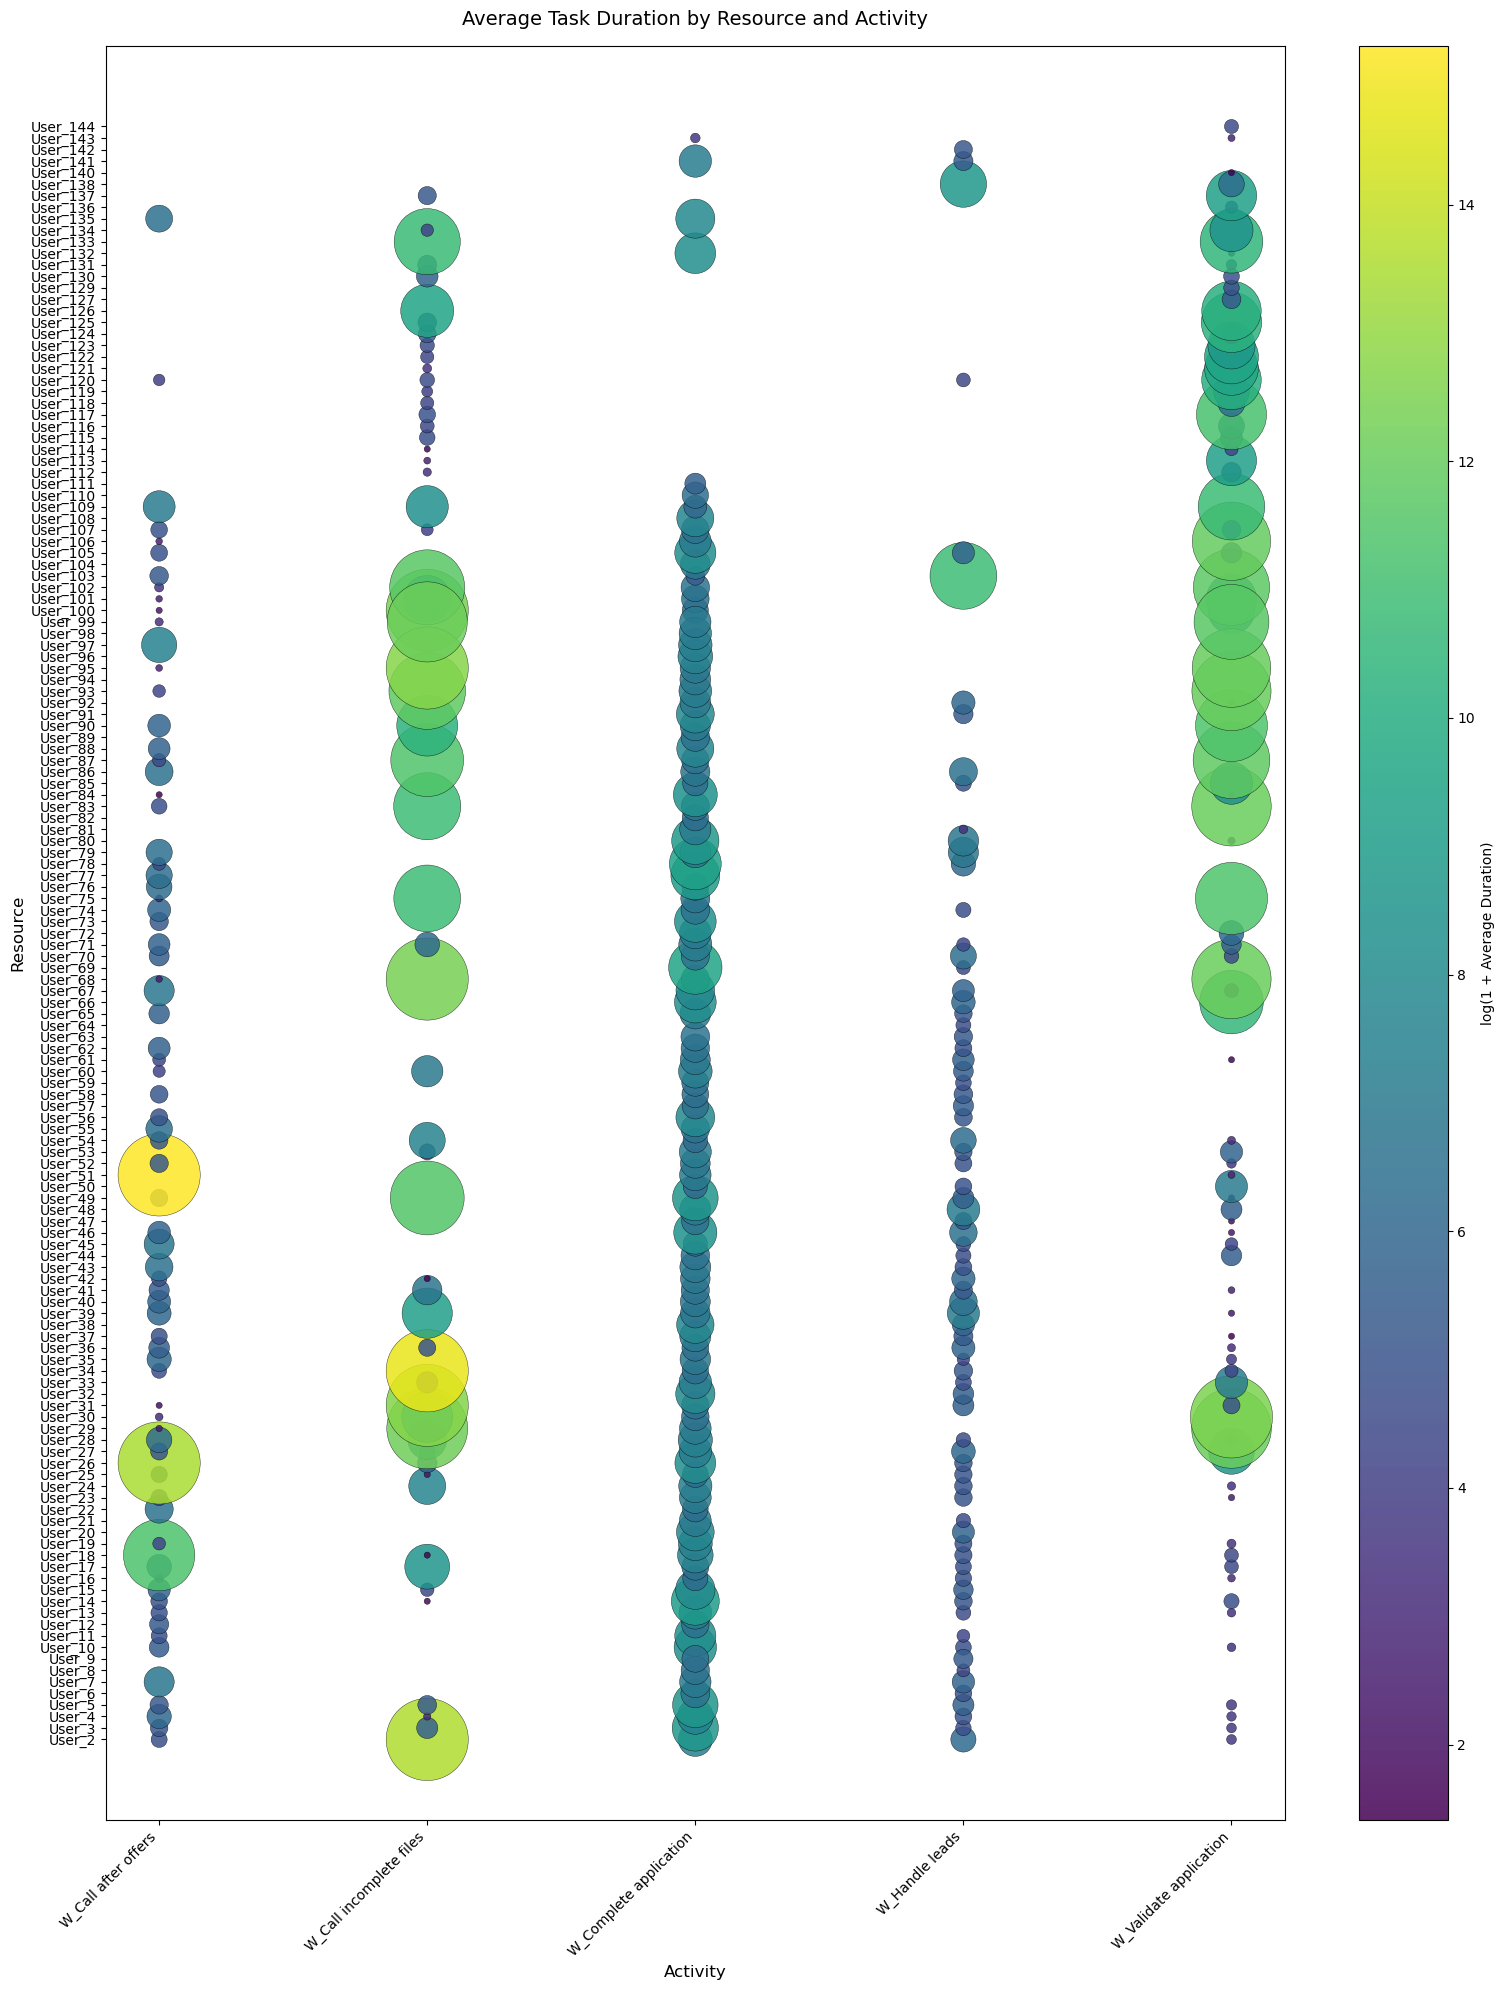

In [30]:
plot_df = resource_activity_avgs.copy()

activities = sorted(plot_df['Activity'].unique())

resources = sorted(
    plot_df['Resource'].unique(), 
    key=lambda x: int(x.split('_')[1]) if '_' in x and x.split('_')[1].isdigit() else 0
)

activity_to_x = {a: i for i, a in enumerate(activities)}
resource_to_y = {r: i for i, r in enumerate(resources)}

x = plot_df["Activity"].map(activity_to_x)
y = plot_df["Resource"].map(resource_to_y)
values = plot_df["AverageDuration"]

log_values = np.log1p(values)
low, high = np.percentile(log_values, [2, 98])
clipped = np.clip(log_values, low, high)

gamma = 2.8
scaled = (clipped - low) / (high - low + 1e-12)
scaled = np.power(scaled, gamma)

min_size, max_size = 20, 3500
sizes = min_size + (max_size - min_size) * scaled

plt.figure(figsize=(16, 20))
scatter = plt.scatter(
    x,
    y,
    s=sizes,
    c=log_values,
    cmap="viridis",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
)

plt.xticks(range(len(activities)), activities, rotation=45, ha="right")
plt.yticks(range(len(resources)), resources)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("Resource", fontsize=12)
plt.title("Average Task Duration by Resource and Activity", fontsize=14, pad=15)
plt.colorbar(scatter, label="log(1 + Average Duration)")

plt.tight_layout()
plt.savefig("files/empirical_cost_matrix_bubble.pdf", format="pdf")
plt.show()

### Machine Learning Approach: CatBoost Regressor

In [31]:
target_col = "Duration"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y_log = np.log1p(df[target_col])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

model = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    depth=8,
    learning_rate=0.05,
    iterations=1000,
    random_seed=42,
    verbose=0
)

model.fit(X_train, y_train_log, eval_set=(X_test, y_test_log), cat_features=["Resource", "Activity", "case:LoanGoal", "case:ApplicationType"])

test_pred_log = model.predict(X_test)
print("CatBoost training complete.")

CatBoost training complete.


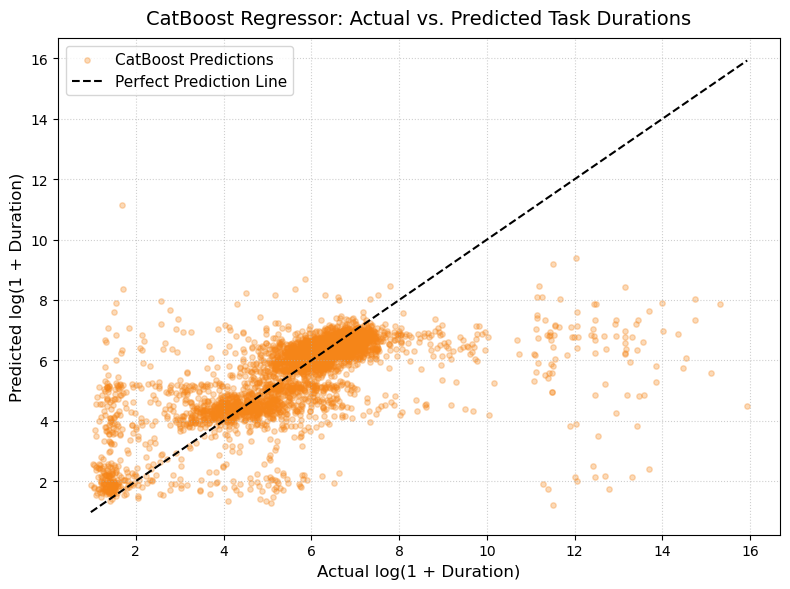

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test_log, test_pred_log, alpha=0.3, s=15, color="#f58518", label="CatBoost Predictions")

min_val = min(y_test_log.min(), test_pred_log.min())
max_val = max(y_test_log.max(), test_pred_log.max())
ax.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1.5, label="Perfect Prediction Line")

ax.set_title("CatBoost Regressor: Actual vs. Predicted Task Durations", fontsize=14, pad=10)
ax.set_xlabel("Actual log(1 + Duration)", fontsize=12)
ax.set_ylabel("Predicted log(1 + Duration)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("files/catboost_prediction_variance.pdf", format="pdf")
plt.show()